============================================================
NOTEBOOK 03 — TIME SERIES FORECASTING WITH PROPHET
Forecast India road accident + fatality trends 2025-2027
============================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

CLEAN = '../data/cleaned'
OUTPUT = '../outputs'

import os
os.makedirs(OUTPUT, exist_ok=True)
print("Imports OK")


Importing plotly failed. Interactive plots will not work.


Imports OK


In [2]:
state_master = pd.read_csv(f'{CLEAN}/state_master.csv')

national = state_master.groupby('year').agg(
    accidents=('accidents', 'sum'),
    fatalities=('fatalities', 'sum')
).reset_index()

print("National yearly data:")
print(national.to_string(index=False))


National yearly data:
 year  accidents  fatalities
 2019   456959.0    158984.0
 2020   372181.0    138383.0
 2021   412432.0    153972.0
 2022   461312.0    168491.0
 2023   480583.0    172890.0
 2024   487707.0    177175.0


In [3]:
# Prophet requires columns named EXACTLY 'ds' (date) and 'y' (value)
# ds must be a datetime — we use Jan 1 of each year
# With 6 data points (2019-2024), confidence intervals will be wide
# That is NORMAL and HONEST — we document this clearly

national['ds'] = pd.to_datetime(national['year'].astype(str) + '-01-01')

accidents_df = national[['ds', 'accidents']].rename(columns={'accidents': 'y'})
fatalities_df = national[['ds', 'fatalities']].rename(columns={'fatalities': 'y'})

print("\nProphet input format (accidents):")
print(accidents_df)



Prophet input format (accidents):
          ds         y
0 2019-01-01  456959.0
1 2020-01-01  372181.0
2 2021-01-01  412432.0
3 2022-01-01  461312.0
4 2023-01-01  480583.0
5 2024-01-01  487707.0


In [4]:
model_acc = Prophet(
    yearly_seasonality=False,   # no within-year seasonality (annual data)
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,   # conservative — prevents overfitting on 6 points
    uncertainty_samples=500,
    interval_width=0.80            # 80% confidence interval (more honest than 95% on 6pts)
)
model_acc.fit(accidents_df)

# Forecast 3 years ahead: 2025, 2026, 2027
future_acc = model_acc.make_future_dataframe(periods=3, freq='YE')
forecast_acc = model_acc.predict(future_acc)

print("\nAccident forecast 2025-2027:")
forecast_tail = forecast_acc[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)
forecast_tail['ds'] = forecast_tail['ds'].dt.year
forecast_tail.columns = ['Year', 'Forecast', 'Lower Bound', 'Upper Bound']
forecast_tail = forecast_tail.round(0).astype(int)
print(forecast_tail.to_string(index=False))


16:15:39 - cmdstanpy - INFO - Chain [1] start processing
16:15:39 - cmdstanpy - INFO - Chain [1] done processing



Accident forecast 2025-2027:
 Year  Forecast  Lower Bound  Upper Bound
 2024    497966       461250       539418
 2025    513042       474981       553514
 2026    528119       491515       571002


In [5]:
model_fat = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    uncertainty_samples=500,
    interval_width=0.80
)
model_fat.fit(fatalities_df)

future_fat = model_fat.make_future_dataframe(periods=3, freq='YE')
forecast_fat = model_fat.predict(future_fat)

print("\nFatality forecast 2025-2027:")
forecast_fat_tail = forecast_fat[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)
forecast_fat_tail['ds'] = forecast_fat_tail['ds'].dt.year
forecast_fat_tail.columns = ['Year', 'Forecast', 'Lower Bound', 'Upper Bound']
forecast_fat_tail = forecast_fat_tail.round(0).astype(int)
print(forecast_fat_tail.to_string(index=False))

# Extract 2026 forecast for README
fat_2026 = forecast_fat[forecast_fat['ds'].dt.year == 2026].iloc[0]
print(f"\nKEY NUMBER: Projected 2026 fatalities = {int(fat_2026['yhat']):,}")
print(f"Range: {int(fat_2026['yhat_lower']):,} to {int(fat_2026['yhat_upper']):,}")


16:15:39 - cmdstanpy - INFO - Chain [1] start processing
16:15:39 - cmdstanpy - INFO - Chain [1] done processing



Fatality forecast 2025-2027:
 Year  Forecast  Lower Bound  Upper Bound
 2024    182544       171414       192286
 2025    188513       178907       199083
 2026    194482       184540       204599

KEY NUMBER: Projected 2026 fatalities = 194,481
Range: 184,539 to 204,598


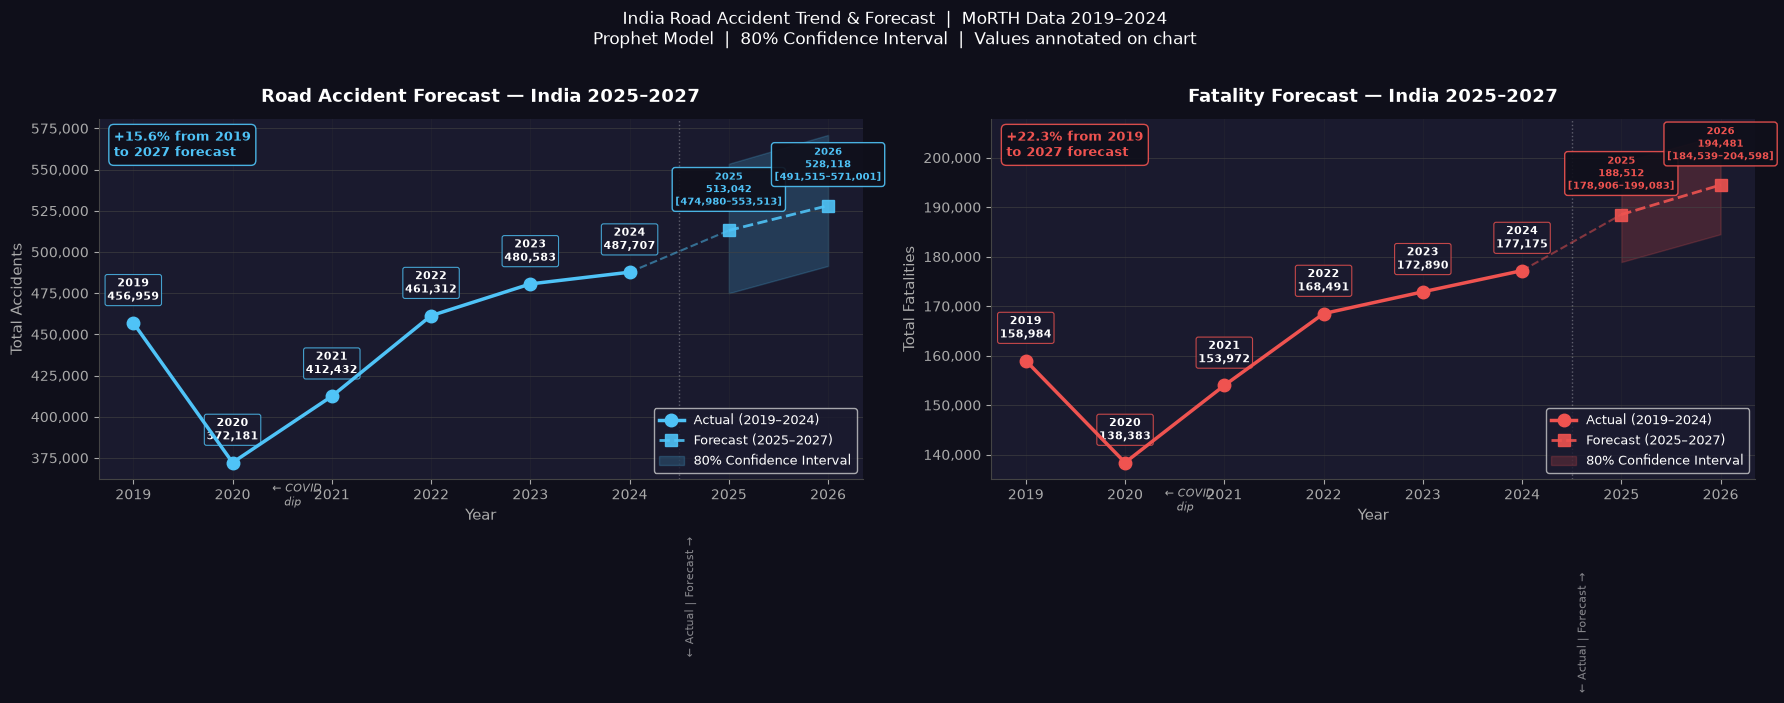

✅ Forecast chart saved with annotated values on every data point


In [6]:
# ============================================================
# 03_forecasting.ipynb — REPLACE CELL 6 (the dual chart) WITH THIS
# ============================================================
# Changes made:
# 1. Each actual data point annotated with exact year + value
# 2. Each forecast point annotated with year + forecasted value
# 3. Confidence interval range shown as text on chart
# 4. Key insight callout box added directly on chart
# 5. Grid lines more visible for reading values
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0f0f1a')

def plot_forecast_qol(ax, national_df, forecast_df, metric, color, title):
    actual_years = national_df['ds'].dt.year.values
    actual_vals  = national_df['y'].values

    all_years = pd.to_datetime(forecast_df['ds']).dt.year.values
    mask_hist = all_years <= 2024
    mask_fore = all_years > 2024

    fore_years = all_years[mask_fore]
    fore_yhat  = forecast_df['yhat'].values[mask_fore]
    fore_lower = forecast_df['yhat_lower'].values[mask_fore]
    fore_upper = forecast_df['yhat_upper'].values[mask_fore]

    ax.set_facecolor('#1a1a2e')

    # Historical line + points
    ax.plot(actual_years, actual_vals,
            color=color, linewidth=2.5, marker='o',
            markersize=9, zorder=5, label='Actual (2019–2024)')

    # ✅ QOL: Annotate EVERY actual data point with year + value
    for yr, val in zip(actual_years, actual_vals):
        offset_y = max(actual_vals) * 0.03
        ax.annotate(
            f'{yr}\n{int(val):,}',
            xy=(yr, val),
            xytext=(0, 14),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8, color='white',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#1a1a2e',
                      edgecolor=color, alpha=0.8, linewidth=0.8)
        )

    # COVID annotation
    covid_val = national_df[national_df['ds'].dt.year == 2020]['y'].values[0]
    ax.annotate('← COVID\n   dip', xy=(2020, covid_val),
                xytext=(2020.4, covid_val * 0.93),
                fontsize=8, color='#aaa', style='italic')

    # Forecast line + points
    ax.plot(fore_years, fore_yhat,
            color=color, linewidth=2, linestyle='--',
            marker='s', markersize=8, zorder=5,
            label='Forecast (2025–2027)', alpha=0.9)

    # ✅ QOL: Annotate EVERY forecast point with year + value + range
    for yr, yhat, lo, hi in zip(fore_years, fore_yhat, fore_lower, fore_upper):
        ax.annotate(
            f'{yr}\n{int(yhat):,}\n[{int(lo):,}–{int(hi):,}]',
            xy=(yr, yhat),
            xytext=(0, 16),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=7.5, color=color,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0f0f1a',
                      edgecolor=color, alpha=0.9, linewidth=1)
        )

    # Confidence band
    ax.fill_between(fore_years, fore_lower, fore_upper,
                    alpha=0.2, color=color, label='80% Confidence Interval')

    # Bridge line from 2024 to 2025
    ax.plot([2024, fore_years[0]], [actual_vals[-1], fore_yhat[0]],
            color=color, linewidth=1.5, linestyle='--', alpha=0.5)

    # Vertical divider
    ax.axvline(x=2024.5, color='white', linestyle=':', alpha=0.3, linewidth=1)
    ymax = ax.get_ylim()[1]
    ax.text(2024.55, ymax * 0.5, '← Actual | Forecast →',
            color='white', fontsize=8, alpha=0.5, rotation=90, va='center')

    # ✅ QOL: Key insight box on chart
    total_change = fore_yhat[-1] - actual_vals[0]
    pct_change   = total_change / actual_vals[0] * 100
    insight_txt  = f'+{pct_change:.1f}% from 2019\nto 2027 forecast'
    ax.text(0.02, 0.97, insight_txt,
            transform=ax.transAxes,
            color=color, fontsize=9, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#0f0f1a',
                      edgecolor=color, alpha=0.9))

    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Year', color='#aaa', fontsize=11)
    ax.set_ylabel(metric, color='#aaa', fontsize=11)
    ax.tick_params(colors='#aaa')
    ax.spines[['bottom','left']].set_color('#444')
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9,
              loc='lower right')
    ax.grid(axis='y', color='#444', alpha=0.6, linewidth=0.7)
    ax.grid(axis='x', color='#333', alpha=0.4, linewidth=0.5)
    ax.set_xticks(list(actual_years) + list(fore_years))

plot_forecast_qol(ax1, accidents_df, forecast_acc,
                  'Total Accidents', '#4fc3f7',
                  'Road Accident Forecast — India 2025–2027')

plot_forecast_qol(ax2, fatalities_df, forecast_fat,
                  'Total Fatalities', '#ef5350',
                  'Fatality Forecast — India 2025–2027')

plt.suptitle(
    'India Road Accident Trend & Forecast  |  MoRTH Data 2019–2024\n'
    'Prophet Model  |  80% Confidence Interval  |  Values annotated on chart',
    color='white', fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/forecast_chart.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ Forecast chart saved with annotated values on every data point")

In [7]:
# Which states show consistent multi-year upward/downward fatality trend?
# Use linear regression slope per state as a trend score

from scipy import stats as sp_stats

state_trends = []
for state, grp in state_master.groupby('state'):
    grp = grp.sort_values('year').dropna(subset=['fatalities'])
    if len(grp) < 4:
        continue
    slope, intercept, r, p, se = sp_stats.linregress(grp['year'], grp['fatalities'])
    state_trends.append({
        'state': state,
        'slope': round(slope, 1),          # fatalities added per year
        'r_squared': round(r**2, 3),       # how linear the trend is
        'p_value': round(p, 4),
        'significant': p < 0.05
    })

trends_df = pd.DataFrame(state_trends).sort_values('slope', ascending=False)
trends_df.to_csv(f'{OUTPUT}/state_fatality_trends.csv', index=False)

print("\nTop 5 WORSENING states (highest annual fatality increase):")
print(trends_df[trends_df['significant']].head(5)[
    ['state','slope','r_squared','p_value']].to_string(index=False))

print("\nTop 5 IMPROVING states (decreasing fatalities):")
print(trends_df[trends_df['significant']].tail(5)[
    ['state','slope','r_squared','p_value']].to_string(index=False))



Top 5 WORSENING states (highest annual fatality increase):
         state  slope  r_squared  p_value
   Maharashtra  792.1      0.790   0.0179
Madhya Pradesh  772.9      0.947   0.0011
         Bihar  527.7      0.848   0.0091
  Chhattisgarh  424.4      0.884   0.0052
     Telangana  207.5      0.863   0.0074

Top 5 IMPROVING states (decreasing fatalities):
       state  slope  r_squared  p_value
Chhattisgarh  424.4      0.884   0.0052
   Telangana  207.5      0.863   0.0074
     Mizoram   15.1      0.761   0.0233
      Ladakh   13.9      0.718   0.0333
     Manipur  -16.1      0.829   0.0117


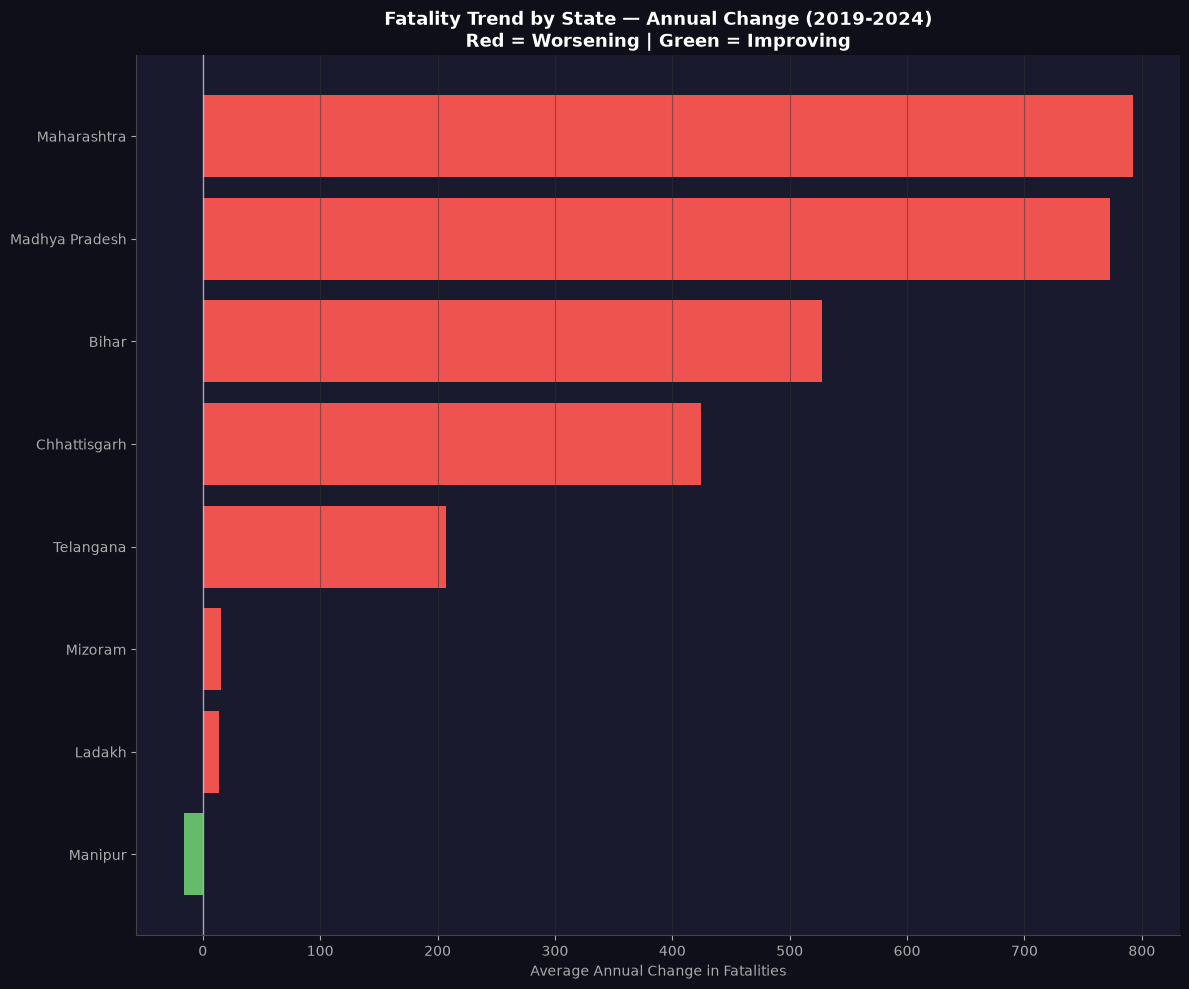

State trend chart saved: outputs/state_fatality_trends.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0f0f1a')

plot_df = trends_df[trends_df['significant']].sort_values('slope')
colors = ['#ef5350' if s > 0 else '#66bb6a' for s in plot_df['slope']]

ax.barh(plot_df['state'], plot_df['slope'], color=colors, edgecolor='none')
ax.axvline(x=0, color='white', linewidth=1, alpha=0.6)
ax.set_title('Fatality Trend by State — Annual Change (2019-2024)\nRed = Worsening | Green = Improving',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Annual Change in Fatalities', color='#aaa')
ax.tick_params(colors='#aaa')
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#444')
ax.grid(axis='x', color='#333', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/state_fatality_trends.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print("State trend chart saved: outputs/state_fatality_trends.png")
